In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import soundfile as sf
from scipy.signal import butter, filtfilt, hilbert

# Calibration

## MRM 1 - JPM 

In [2]:
# load FLAC file
input_flac_file = "ManualRockMovements-1/audio/Nicole_091823-000100.flac"
data, samplerate = sf.read(input_flac_file)

# if stereo (more than one channel), keep only one channel
if data.ndim > 1:
    data = data[:,0] # keep the left channel, which in this case is the impact pipe

Gain Compensation

In [3]:
preamp_gain_db = 23  # preamp gain in dB for this recording
linear_gain = 10**(preamp_gain_db / 20)
calibrated_data = data / linear_gain

print(f"Sampling Rate: {samplerate} Hz")
print(f"Original data shape: {data.shape}")
print(f"Linear gain factor: {linear_gain:.2f}")

Sampling Rate: 44100 Hz
Original data shape: (52920000,)
Linear gain factor: 14.13


### Band-Pass Filtering 

Filter Order Selection

In [4]:
def band_pass_filter(data, samplerate, low, high, order):
    nyquist = 0.5 * samplerate
    low = low / nyquist
    high = high / nyquist
    b, a = butter(order, [low, high], btype='band') # get filter coefficients
    filtered_data = filtfilt(b, a, data)
    return filtered_data

Filter Data and Amplify 

In [5]:
lowcut = 700  # low cutoff frequency in Hz
highcut = 1500 # high cutoff frequency in Hz

# first band-pass filter the entire calibrated data
filtered_data1 = band_pass_filter(calibrated_data, samplerate, lowcut, highcut, order=4)
filtered_data2 = filtered_data1 * 20

# second band-pass filter
filtered_data3 = band_pass_filter(filtered_data2, samplerate, lowcut, highcut, order=4)
filtered_data = filtered_data3 * 10

### Envelope Detection

Subsample for envelope

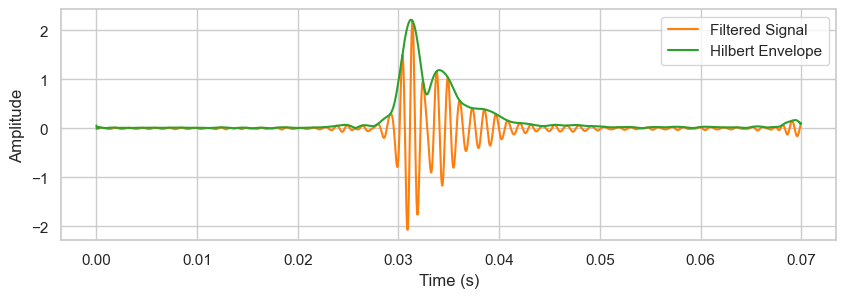

In [6]:
subsample = filtered_data[int(41.73 * samplerate):int(41.8 * samplerate)]
subtime = np.arange(len(subsample)) / samplerate

# visualize the filtered signal
import seaborn as sns
# using the hilbert transform 
analytic_signal = hilbert(subsample)
envelope_hilbert = np.abs(analytic_signal)

# visualize the envelope
sns.set(style="whitegrid")
plt.figure(figsize=(10, 3))
plt.plot(subtime, subsample, color='#ff7f0e', label='Filtered Signal')
plt.plot(subtime, envelope_hilbert, color='#2ca02c', linewidth=1.5, label='Hilbert Envelope')
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.savefig("example_envelope_zoomed.png", dpi=300)
plt.show()


Full Sample

In [7]:
# using the hilbert transform 
#filteredsample = filtered_data[int(41.3 * samplerate):int(41.9 * samplerate)]
filteredsample = filtered_data[int(41.74 * samplerate):int(41.79 * samplerate)]
time = np.arange(len(filteredsample)) / samplerate  # Changed from subsample
nyquist = 0.5 * samplerate
analytic_signal = hilbert(filteredsample)  # Changed from subsample
envelope_hilbert = np.abs(analytic_signal)

# using rectification and low-pass filter
cutoff_freq_envelope = 100 # # low low-pass filter to smooth the rectified signal
low_pass_cutoff = cutoff_freq_envelope / nyquist
b_lp, a_lp = butter(2, low_pass_cutoff, btype='low')
envelope_rectified = filtfilt(b_lp, a_lp, np.abs(filteredsample))  # Changed from subsample

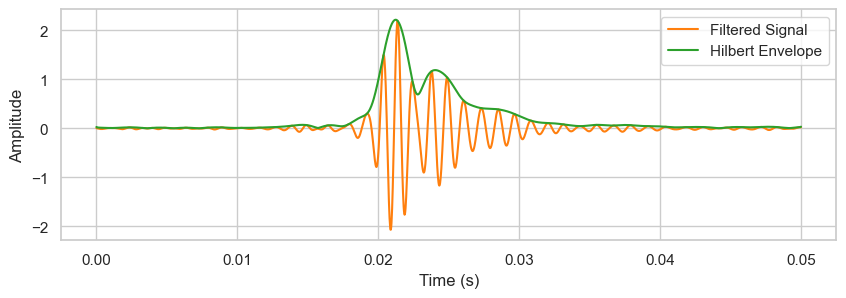

In [8]:
# visualize the envelopes
sns.set(style="whitegrid")
plt.figure(figsize=(10, 3))
plt.plot(time, filteredsample, '#ff7f0e', label='Filtered Signal')
plt.plot(time, envelope_hilbert, '#2ca02c', linewidth=1.5, label='Hilbert Envelope')
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend(loc='upper right')
#plt.savefig("calibration_plots/MRM1/test_signal_envelopes_full.png", dpi=300)
plt.show()

### Pulse counting and Rectangular waveform

Compute and plot the rectangular waveforms

In [9]:
# channel gains (relative multipliers) from 
gains = {
    6: 1,
    5: 4,
    4: 16,
    3: 64,
    2: 256,
    1: 1024
}

# voltage thresholds for impulse detection
lower_thresh = 2  # volts
# first column of results is the time index of detected impulses
rect_hilbert = pd.DataFrame({'time': time})

# loop over channels, apply gain, and detect impulses
# for hilbert envelope
for ch, gain in gains.items():
    amplified = envelope_hilbert * gain
    # create binary array: 1 if in threshold, else 0
    binary = ((amplified > lower_thresh)).astype(int)
    # convert to 5 V pulse
    rectangular = binary * 5
    rect_hilbert[f'ch{ch}'] = rectangular

del amplified, binary, rectangular, ch, gain

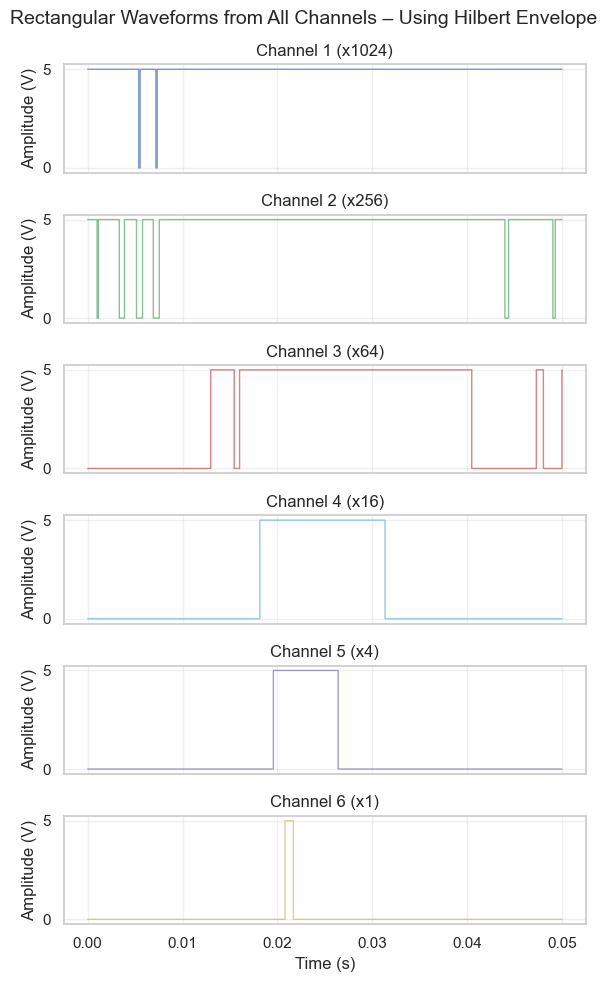

In [10]:
fig, axes = plt.subplots(6, 1, figsize=(6, 10), sharex=True)

channels = ['ch1', 'ch2', 'ch3', 'ch4', 'ch5', 'ch6']
colors = ['b', 'g', 'r', 'c', 'm', 'y']
channel_gains = [1024, 256, 64, 16, 4, 1]

plot_time = rect_hilbert['time'].to_numpy()

for i, (ch, color, gain) in enumerate(
        zip(channels, colors, channel_gains)):

    plot_signal = rect_hilbert[ch].to_numpy()

    axes[i].step(
        plot_time,
        plot_signal,
        where='post',
        color=color,
        alpha=0.7,
        linewidth=1
    )

    axes[i].set_ylabel("Amplitude (V)")
    axes[i].set_title(f"Channel {i + 1} (x{gain})")
    axes[i].set_ylim(-0.25, 5.25)
    axes[i].set_yticks([0, 5])
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (s)")

plt.suptitle(
    "Rectangular Waveforms from All Channels – Using Hilbert Envelope",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [11]:
# Channel gains
channel_gains = {
    1: 1024,
    2: 256,
    3: 64,
    4: 16,
    5: 4,
    6: 1
}

lower_thresh = 2  # threshold after amplification, in volts
# Store time and rectangular waveforms
rect_hilbert = pd.DataFrame({"time": time})

for ch, gain in channel_gains.items():

    # Apply the channel gain
    amplified_envelope = envelope_hilbert * gain
    # 5 V when the amplified envelope exceeds 2 V; otherwise 0 V
    rectangular_waveform = np.where(
        amplified_envelope > lower_thresh,
        5.0,
        0.0
    )

    rect_hilbert[f"ch{ch}"] = rectangular_waveform

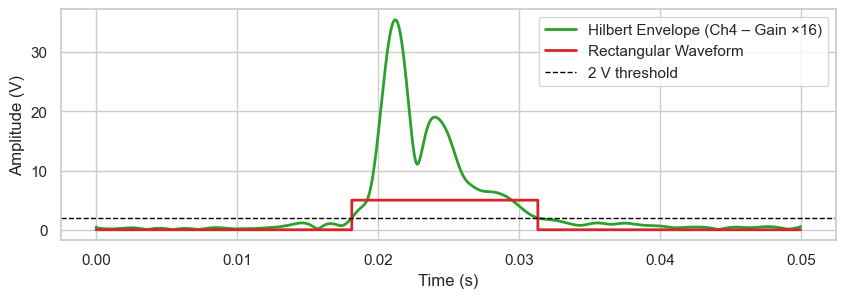

In [12]:
plt.figure(figsize=(10, 3))

plt.plot(time, envelope_hilbert * 16, color="#2ca02c", linewidth=2, label="Hilbert Envelope (Ch4 – Gain ×16)")
plt.step(time, rect_hilbert["ch4"], where="post", color="#d62728", linewidth=2, label="Rectangular Waveform")
plt.axhline(lower_thresh, color="black", linestyle="--", linewidth=1, label="2 V threshold")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude (V)")
plt.legend(loc="upper right")
plt.show()

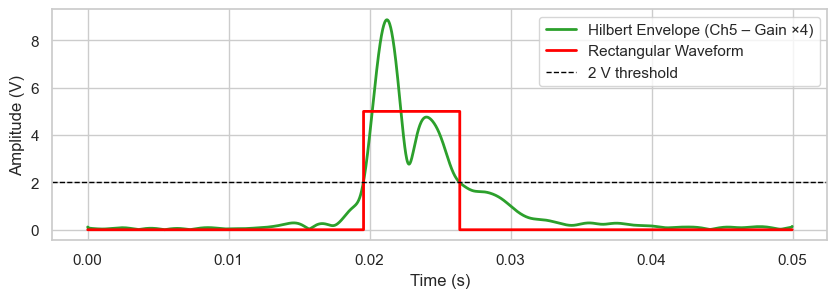

In [13]:
plt.figure(figsize=(10, 3))

plt.plot(time, envelope_hilbert * 4, color="#2ca02c", linewidth=2, label="Hilbert Envelope (Ch5 – Gain ×4)")
plt.step(time, rect_hilbert["ch5"], where="post", color="red", linewidth=2, label="Rectangular Waveform")
plt.axhline(lower_thresh, color="black", linestyle="--", linewidth=1, label="2 V threshold")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude (V)")
plt.legend(loc="upper right")
plt.show()

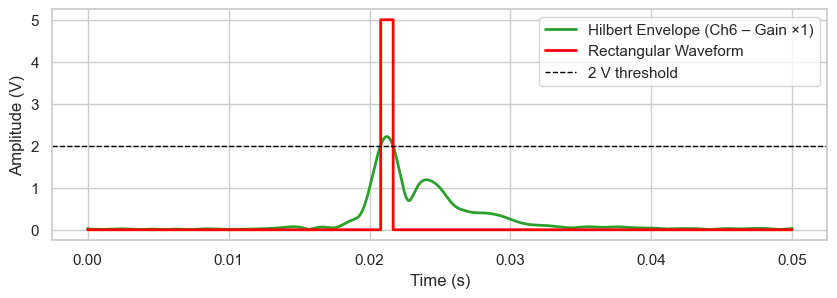

In [14]:
plt.figure(figsize=(10, 3))

plt.plot(time, envelope_hilbert * 1, color="#2ca02c", linewidth=2, label="Hilbert Envelope (Ch6 – Gain ×1)")
plt.step(time, rect_hilbert["ch6"], where="post", color="red", linewidth=2, label="Rectangular Waveform")
plt.axhline(lower_thresh, color="black", linestyle="--", linewidth=1, label="2 V threshold")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude (V)")
plt.legend(loc="upper right")
plt.show()

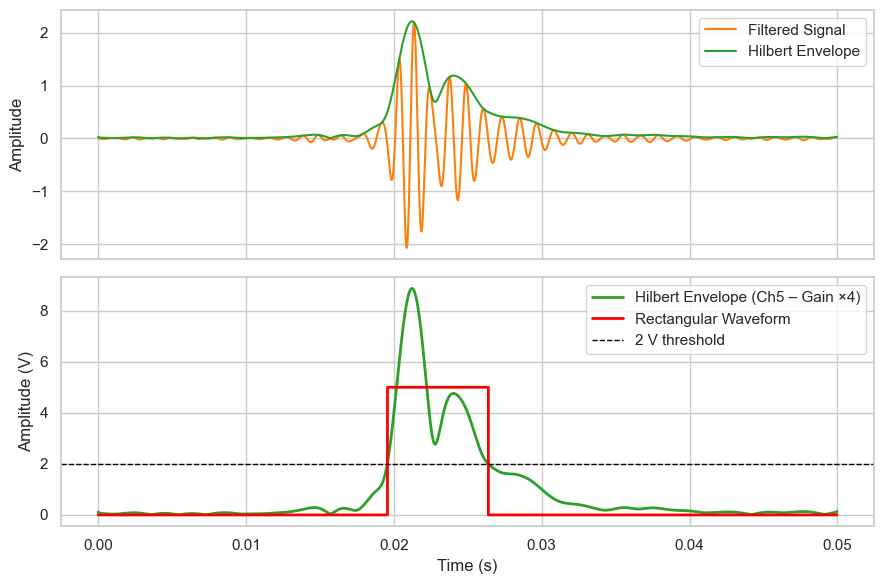

In [16]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# Top plot
axes[0].plot(time, filteredsample, color="#ff7f0e", label="Filtered Signal")
axes[0].plot(time, envelope_hilbert, color="#2ca02c", linewidth=1.5, label="Hilbert Envelope")
axes[0].set_ylabel("Amplitude")
axes[0].legend(loc="upper right")

# Bottom plot
axes[1].plot(
    time,
    envelope_hilbert * 4,
    color="#2ca02c",
    linewidth=2,
    label="Hilbert Envelope (Ch5 – Gain ×4)"
)
axes[1].step(
    time,
    rect_hilbert["ch5"],
    where="post",
    color="red",
    linewidth=2,
    label="Rectangular Waveform"
)
axes[1].axhline(
    lower_thresh,
    color="black",
    linestyle="--",
    linewidth=1,
    label="2 V threshold"
)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude (V)")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.savefig("test_envelopes_and_pulse_example.png", dpi=300)
plt.show()